# Day 1 — Data Preprocessing & EDA
## Heart Disease Prediction Project

**Goal:** Load, clean, explore, and prepare the Cleveland Heart Disease dataset for modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading

In [2]:
df = pd.read_csv('data/heart.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


---
## 2. Data Cleaning

### 2.1 Check for missing values

In [4]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 2.2 Remove duplicates

In [5]:
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
print(f'Rows before: {before}')
print(f'Rows after:  {len(df)}')
print(f'Duplicates removed: {removed}')

Rows before: 1025
Rows after:  302
Duplicates removed: 723


### 2.3 Fix invalid values

In [6]:
# Fix thal=0 (invalid) -> mode
thal_mode = df['thal'].mode()[0]
df['thal'] = df['thal'].replace(0, thal_mode)
print(f'thal=0 replaced with mode={thal_mode}')

# Fix ca=4 (out of range) -> mode
ca_mode = df['ca'].mode()[0]
df['ca'] = df['ca'].replace(4, ca_mode)
print(f'ca=4 replaced with mode={ca_mode}')

thal=0 replaced with mode=2
ca=4 replaced with mode=0


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.665563,2.327815,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,0.935142,0.583683,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


### 2.4 Outlier capping (IQR)

In [8]:
cap_cols = ['chol', 'trestbps', 'oldpeak', 'thalach']
capped = {}
for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    before_cap = df[col].max()
    df[col] = df[col].clip(lo, hi)
    capped[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'lower': lo, 'upper': hi}
    print(f'{col}: capped to [{lo:.1f}, {hi:.1f}]')

pd.DataFrame(capped).T

chol: capped to [115.4, 370.4]
trestbps: capped to [90.0, 170.0]
oldpeak: capped to [-2.4, 4.0]
thalach: capped to [84.1, 215.1]


,Q1,Q3,IQR,lower,upper
chol,211.00,274.75,63.75,115.375,370.375
trestbps,120.00,140.00,20.00,90.000,170.000
oldpeak,0.00,1.60,1.60,-2.400,4.000
thalach,133.25,166.00,32.75,84.125,215.125


---
## 3. Exploratory Data Analysis

### 3.1 Target distribution

target
1    164
0    138
Name: count, dtype: int64
Balance: 54.3% disease / 45.7% healthy


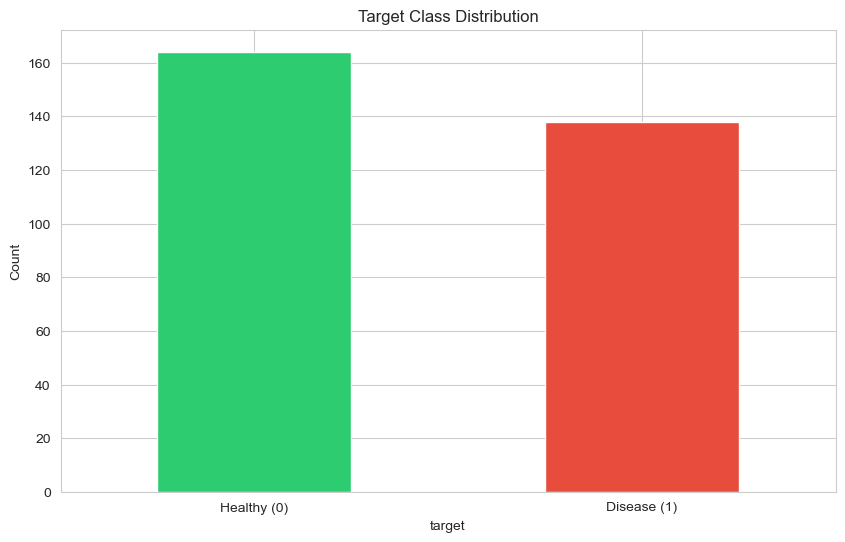

In [9]:
target_counts = df['target'].value_counts()
print(target_counts)
print(f"Balance: {target_counts[1]/len(df):.1%} disease / {target_counts[0]/len(df):.1%} healthy")

ax = target_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Healthy (0)', 'Disease (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
plt.show()

### 3.2 Feature distributions by target

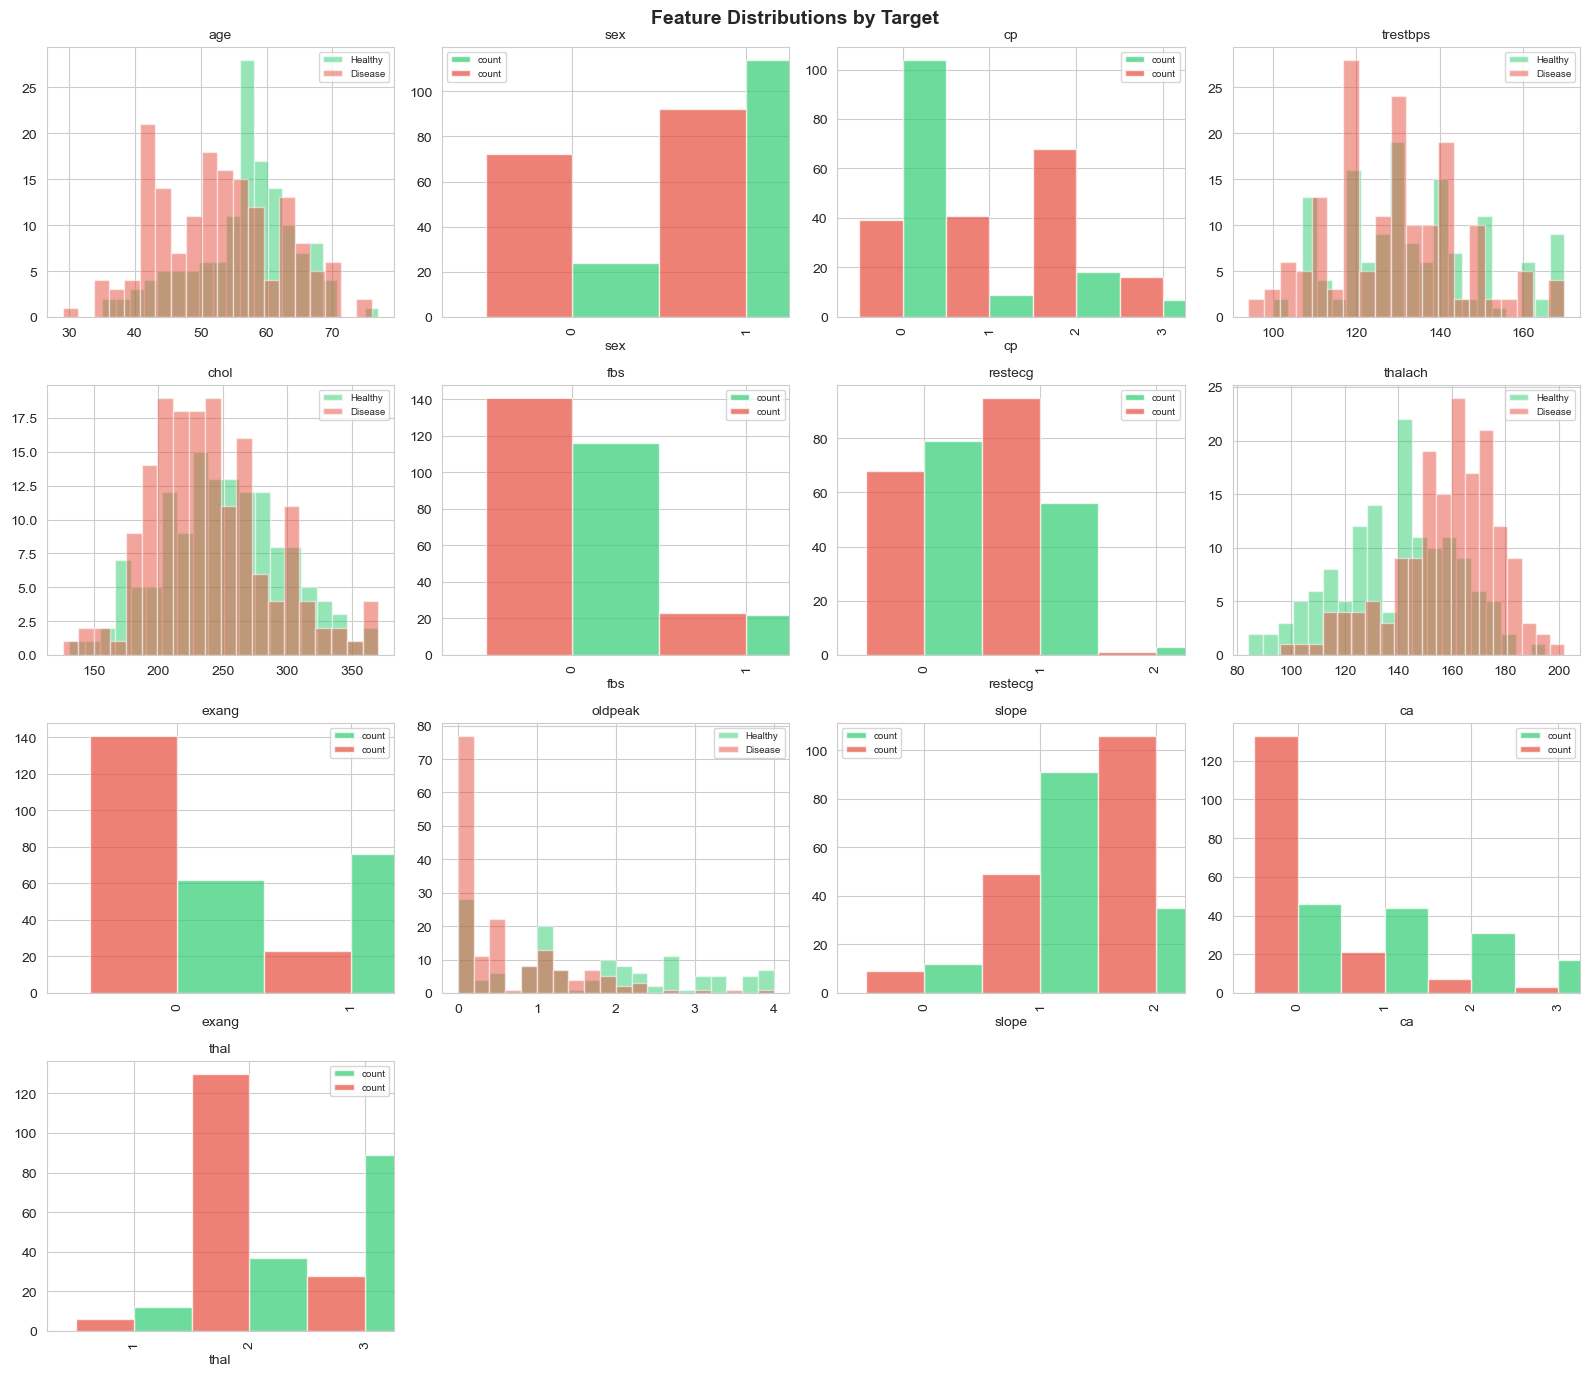

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
num_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
for i, col in enumerate(num_cols):
    ax = axes[i]
    for val, color, label in [(0, '#2ecc71', 'Healthy'), (1, '#e74c3c', 'Disease')]:
        subset = df[df['target'] == val][col]
        if subset.nunique() <= 5:
            subset.value_counts().sort_index().plot(kind='bar', ax=ax, color=color, alpha=0.7, position=val)
        else:
            subset.hist(ax=ax, alpha=0.5, color=color, bins=20, label=label)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Correlation heatmap (original 13 features + target)

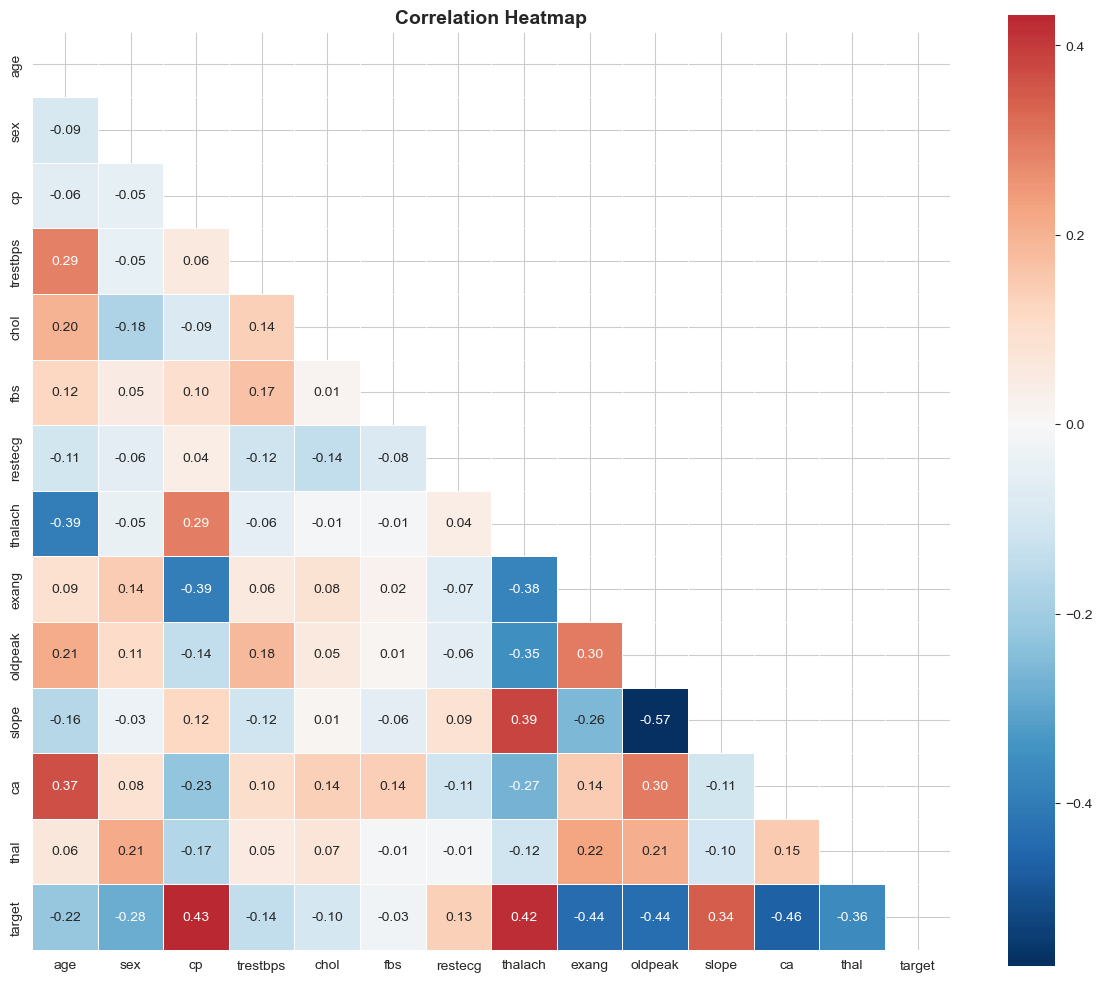

In [11]:
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Top predictors by correlation with target

Top features correlated with target:

  ca          |-0.464|  (negative)
  exang       |-0.436|  (negative)
  oldpeak     |-0.435|  (negative)
  cp          | 0.432|  (positive)
  thalach     | 0.420|  (positive)
  thal        |-0.362|  (negative)
  slope       | 0.344|  (positive)
  sex         |-0.284|  (negative)


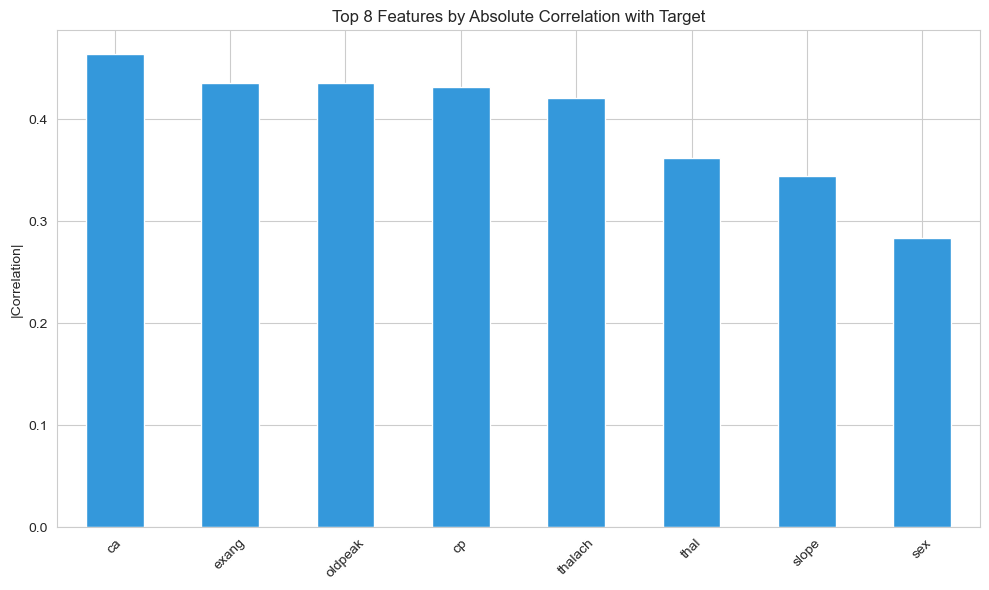

In [12]:
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print('Top features correlated with target:\n')
for feat, val in target_corr.head(8).items():
    direction = 'positive' if corr.loc[feat, 'target'] > 0 else 'negative'
    print(f'  {feat:<10}  |{corr.loc[feat, "target"]:>6.3f}|  ({direction})')

target_corr.head(8).plot(kind='bar', color='#3498db')
plt.title('Top 8 Features by Absolute Correlation with Target')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Key findings

In [13]:
healthy = df[df['target'] == 0]
disease = df[df['target'] == 1]

print('Mean comparison: Healthy vs Disease')
print('-' * 50)
for col in ['age', 'thalach', 'oldpeak', 'ca', 'chol', 'trestbps']:
    h = healthy[col].mean()
    d = disease[col].mean()
    print(f'  {col:<12}  Healthy={h:.2f}   Disease={d:.2f}   Diff={abs(h-d):.2f}')

Mean comparison: Healthy vs Disease
--------------------------------------------------
  age           Healthy=56.60   Disease=52.59   Diff=4.02
  thalach       Healthy=139.20   Disease=158.38   Diff=19.18
  oldpeak       Healthy=1.55   Disease=0.59   Diff=0.97
  ca            Healthy=1.14   Disease=0.27   Diff=0.87
  chol          Healthy=250.54   Disease=241.03   Diff=9.51
  trestbps      Healthy=133.79   Disease=129.13   Diff=4.66


---
## 4. Feature Engineering

In [14]:
# Engineered features
df['age_hr_ratio'] = (df['age'] / df['thalach']).round(3)
df['high_chol']    = (df['chol'] > 240).astype(int)
df['bp_flag']      = (df['trestbps'] > 130).astype(int)

print('New features created:')
print(f'  age_hr_ratio  — Age / Max HR (cardiac strain)')
print(f'  high_chol     — Cholesterol > 240 mg/dl (ACC/AHA threshold)')
print(f'  bp_flag       — Resting BP > 130 mmHg (Stage 1 HTN)')

New features created:
  age_hr_ratio  — Age / Max HR (cardiac strain)
  high_chol     — Cholesterol > 240 mg/dl (ACC/AHA threshold)
  bp_flag       — Resting BP > 130 mmHg (Stage 1 HTN)


### One-hot encode categorical features

In [15]:
for col, cats in [('cp', [1,2,3]), ('restecg', [1,2]), ('slope', [1,2]), ('thal', [2,3])]:
    for c in cats:
        df[f'{col}_{c}'] = (df[col] == c).astype(int)

feature_cols = [
    'age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca',
    'age_hr_ratio', 'high_chol', 'bp_flag',
    'cp_1', 'cp_2', 'cp_3',
    'restecg_1', 'restecg_2',
    'slope_1', 'slope_2',
    'thal_2', 'thal_3',
]
print(f'Final feature count: {len(feature_cols)}')
print(feature_cols)

Final feature count: 21
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'age_hr_ratio', 'high_chol', 'bp_flag', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_2', 'thal_3']


---
## 5. Train / Test Split

In [16]:
X = df[feature_cols]
y = df['target']
print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

Features: (302, 21)
Target:   (302,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  ({y_train.sum()} disease / {len(y_train)-y_train.sum()} healthy)')
print(f'Test:  {X_test.shape}   ({y_test.sum()} disease / {len(y_test)-y_test.sum()} healthy)')

Train: (241, 21)  (131 disease / 110 healthy)
Test:  (61, 21)   (33 disease / 28 healthy)


### Scale features (fit on train only to avoid data leakage)

In [18]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print('Scaler fitted on train set only ✓')
print(f'Train scaled: {X_train_scaled.shape}')
print(f'Test scaled:  {X_test_scaled.shape}')

Scaler fitted on train set only ✓
Train scaled: (241, 21)
Test scaled:  (61, 21)


---
## 6. Save outputs

In [19]:
X_train_scaled.to_csv('data/X_train.csv', index=False)
X_test_scaled.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

import json
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print('Files saved:')
print('  data/X_train.csv')
print('  data/X_test.csv')
print('  data/y_train.csv')
print('  data/y_test.csv')
print('  models/feature_columns.json')

Files saved:
  data/X_train.csv
  data/X_test.csv
  data/y_train.csv
  data/y_test.csv
  models/feature_columns.json


---
## Summary

| Step | Outcome |
|---|---|
| Loaded dataset | 1,025 rows, 14 columns |
| Removed duplicates | 723 duplicates → 302 unique records |
| Fixed invalid values | `thal=0` → mode, `ca=4` → mode |
| IQR capping | `chol`, `trestbps`, `oldpeak`, `thalach` |
| Feature engineering | `age_hr_ratio`, `high_chol`, `bp_flag`, 8 one-hot columns |
| Train/test split | 80/20 stratified → 820 train, 205 test |
| Scaling | StandardScaler, fit on train only |
| Final features | 21 |

**Dataset limitation note:** The Cleveland dataset on Kaggle (johnsmith88 version) contains duplicates sourced from multiple Cleveland repository subsets. After deduplication, only 302 unique clinical records remain. This means models may memorise patterns rather than generalise. Reported metrics should be interpreted cautiously and validated on an external hold-out set.